In [1]:
import numpy as np
import pandas as pd
import math

In [2]:
# import synthetic landscape

data_folder = ''

lscape_name_notxt = 'FERM_zone0'

img_folder = '' + lscape_name_notxt + '/'

synscape = pd.read_csv(data_folder + lscape_name_notxt + '.txt', sep=' ')
print(synscape.shape)
print(synscape.columns)

(211229, 33)
Index(['xpos', 'ypos', 'zpos', 'tens', 'fric', 'coh', 'C:Tau', 'ssr', 'ssi',
       'smax', 'smid', 'smin', 'sxx', 'sxy', 'sxz', 'syy', 'syz', 'szz', 'vsi',
       'vsr', 'xxr', 'yyr', 'zzr', 'xyr', 'yzr', 'xzr', 'xxi', 'yyi', 'zzi',
       'xyi', 'yzi', 'xzi', 'diff-str'],
      dtype='object')


In [3]:
# reconstruct near-surface layer

# binning as a tool to find the surface elevation
# at each approximate location
# and determine depth to keep below that surface
# actual node positions will be irregular xpos, ypos, zpos

In [4]:
# 1. group nearby points into 60-unit spatial bins
bin_size = 60

synscape['xbin'] = (synscape['xpos'] // bin_size).astype(int)
synscape['ybin'] = (synscape['ypos'] // bin_size).astype(int)
print('bins grouped')

bins grouped


In [5]:
# 2. find surface elevation per bin
surface_z = synscape.groupby(['xbin','ybin'])['zpos'].max().reset_index()
surface_z.columns = ['xbin', 'ybin', 'z_surface']

synscape = synscape.merge(surface_z, on=['xbin','ybin'], how='left')
synscape['depth_below_surface'] = synscape['z_surface'] - synscape['zpos']
print('surface elev found')

surface elev found


In [6]:
# 3. determine near-surface layer
depth_band = 50
surface_layer = synscape[synscape['depth_below_surface'] <= depth_band].copy()
surface_layer = surface_layer.reset_index(drop=True)
print('near-surface layer determined')

near-surface layer determined


In [7]:
# print results
print(f"near-surface points: {len(surface_layer)}")
print(f"depth range: {surface_layer['depth_below_surface'].min():.2f} "
      f"to {surface_layer['depth_below_surface'].max():.2f}")
print(f"C:Tau range: {surface_layer['C:Tau'].min():.4f} "
      f"to {surface_layer['C:Tau'].max():.4f}")
print(f"C:Tau mean: {surface_layer['C:Tau'].mean():.4f}")

near-surface points: 12165
depth range: 0.00 to 50.00
C:Tau range: 0.0000 to 10.0000
C:Tau mean: 1.6095


# build k-nearest neighbor graph (original)

from sklearn.neighbors import BallTree
import numpy as np

# use horizontal coordinates only for neighbor search
# depth_below_surface as node feature, not connectivity criterion
coords_2d = surface_layer[['xpos','ypos']].values

# k nearest neighbors in horizontal plane
k = 8 # cardianal + diagonal analog for irregular grid

tree = BallTree(coords_2d)
distances, indices = tree.query(coords_2d, k=k+1) # +1 because point is its own neighbor

# remove self (index 0)
distances = distances[:, 1:]
indices = indices[:, 1:]

print(f"neighbor distances -- mean: {distances.mean():.2f}, "
      f"max: {distances.max():.2f}, min: {distances.min():.2f}")

# build k-nearest edge list
rows, cols, edge_weights = [], [], []
for i in range(len(surface_layer)):
    for j, dist in zip(indices[i], distances[i]):
        if dist > 0:
            rows.append(i)
            cols.append(j)
            edge_weights.append(1.0 / dist) # inverse distance weight

print(f"total directed edges: {len(rows)}")
print(f"undirected edges: {len(rows) // 2}")

# build clean undirected edge set (original)
edge_dict0 = {} # (min_idx, max_idx) -> weight

for i in range(len(surface_layer)):
    for j, dist in zip(indices[i], distances[i]):
        if dist < 1e-6: # skip zero distance
            continue
        key = (min(i,j), max(i,j)) # canonical undirected key
        w = 1.0 / dist # inverse distance weight
        if key not in edge_dict: # avoid repeat edges
            edge_dict[key] = w
        else:
            edge_dict[key] = max(edge_dict[key], w) # take stronger connection

edge_pairs0 = list(edge_dict.keys())
edge_weights_clean0 = [edge_dict[k] for k in edge_pairs]

print(f"clean undirected edges: {len(edge_pairs0)}")
print(f"weight range: {min(edge_weights_clean0):.6f} to {max(edge_weights_clean0):.6f}")

In [10]:
# rebuild graph using radius query
# connect to all nodes within {150} units
# minus any within {10} units (avoid vertical stacking)
# variable node degree more honest representation
# of irregularly spaced data

from sklearn.neighbors import BallTree
import numpy as np

# use horizontal coordinates only for neighbor search
# depth_below_surface as node feature, not connectivity criterion
coords_2d = surface_layer[['xpos','ypos']].values

min_dist = 10.0
max_dist = 100.0

tree = BallTree(coords_2d)

# query by radius -- only neighbors within max_dist
indices_r, distances_r = tree.query_radius(coords_2d,
                                           r=max_dist,
                                           return_distance=True,
                                           sort_results=True)

# build clean undirected edge set
edge_dict = {}

for i in range(len(surface_layer)):
    for j, dist in zip(indices_r[i], distances_r[i]):
        if i == j or dist < min_dist: # skip self and too-close
            continue
        key = (min(i,j), max(i,j))
        w = 1.0 / dist # inverse distance weighting
        if key not in edge_dict:
            edge_dict[key] = w
        else:
            edge_dict[key] = max(edge_dict[key], w) # take stronger connection

edge_pairs = list(edge_dict.keys())
edge_weights_clean = [edge_dict[k] for k in edge_pairs]

print(f"clean undirected edges: {len(edge_pairs)}")
print(f"weight range: {min(edge_weights_clean):.6f} to {max(edge_weights_clean):.6f}")
print(f"mean weight: {np.mean(edge_weights_clean):.6f}")

all_nodes = set(i for pair in edge_pairs for i in pair)
print(f"connected nodes: {len(all_nodes)} of {len(surface_layer)}")
print(f"isolated nodes: {len(surface_layer) - len(all_nodes)}")

clean undirected edges: 77119
weight range: 0.010000 to 0.021190
mean weight: 0.015886
connected nodes: 12165 of 12165
isolated nodes: 0


In [12]:
# assemble node features and labels

# for now only position and depth
# have not built topographic features

feature_cols = ['xpos','ypos','zpos','depth_below_surface']

n_features=len(feature_cols)

# target
label_col = 'C:Tau'

# normalize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(surface_layer[feature_cols].values)
y = surface_layer[label_col].values.astype(np.float32)

print(f"node features shape: {X.shape}")
print(f"labels shape: {y.shape}")
print(f"C:Tau range: {y.min():.4f} to {y.max():.4f}")

node features shape: (12165, 4)
labels shape: (12165,)
C:Tau range: 0.0000 to 10.0000


In [13]:
import torch
from torch_geometric.data import Data

# build edge index and weights for PyG
edge_index = torch.tensor([[i for i,j in edge_pairs] + [j for i,j in edge_pairs],
                           [j for i,j in edge_pairs] + [i for i,j in edge_pairs]],
                          dtype=torch.long)

edge_attr = torch.tensor(edge_weights_clean + edge_weights_clean,
                         dtype=torch.float32).unsqueeze(1)

x_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

data = Data(x=x_tensor, edge_index=edge_index,
            edge_attr=edge_attr, y=y_tensor)

print(f"\n PyG Data object")
print(data)


 PyG Data object
Data(x=[12165, 4], edge_index=[2, 154238], edge_attr=[154238, 1], y=[12165])


In [14]:
# train/test split
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.transforms import RandomNodeSplit

# train/test split on nodes
torch.manual_seed(42)
n_nodes = data.num_nodes
perm = torch.randperm(n_nodes)
train_size = int(0.8 * n_nodes)

train_mask = torch.zeros(n_nodes, dtype=torch.bool)
test_mask = torch.zeros(n_nodes, dtype=torch.bool)
train_mask[perm[:train_size]] = True
test_mask[perm[train_size:]] = True

data.train_mask = train_mask
data.test_mask = test_mask

print(f"train nodes: {train_mask.sum().item()}")
print(f"test nodes: {test_mask.sum().item()}")

train nodes: 9732
test nodes: 2433


In [15]:
# simple GraphSAGE regressor
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.conv3 = SAGEConv(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = self.lin(x)
        return x.squeeze()

In [16]:
model = GraphSAGE(in_channels=n_features, hidden_channels=64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

print(f"\nmodel paramaters: {sum(p.numel() for p in model.parameters())}")


model paramaters: 17153


In [17]:
# training loop
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.mse_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test():
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
    pred = out[data.test_mask].numpy()
    true = data.y[data.test_mask].numpy()
    ss_res = ((true - pred) ** 2 ).sum()
    ss_tot = ((true - true.mean()) ** 2).sum()
    return 1 - ss_res /ss_tot

In [18]:
# run training
for epoch in range(1, 201):
    loss = train()
    if epoch % 20 == 0:
        r2 = test()
        print(f"epoch {epoch:3d}: loss={loss:.4f}, test R^2={r2:.4f}")

epoch  20: loss=1.2645, test R^2=0.1790
epoch  40: loss=1.1261, test R^2=0.2495
epoch  60: loss=1.0752, test R^2=0.2890
epoch  80: loss=1.0458, test R^2=0.2974
epoch 100: loss=1.0418, test R^2=0.3058
epoch 120: loss=1.0377, test R^2=0.3117
epoch 140: loss=1.0307, test R^2=0.3118
epoch 160: loss=1.0200, test R^2=0.3192
epoch 180: loss=1.0100, test R^2=0.3171
epoch 200: loss=1.0118, test R^2=0.3221


In [21]:
# assess model's ability to categorize landscape nodes
# as unstable (failure), critical, and stable 

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def bin_ctau(values):
    """Bin C:Tau into three stability categories."""
    bins = np.zeros(len(values), dtype=int)
    bins[values < 0.9] = 0              # unstable (failure)
    bins[(values >= 0.9) & (values <= 1.1)] = 1 # critical
    bins[values > 1.1] = 2              # stable
    return bins


In [22]:
# get predictions on full test set
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)

pred = out.numpy()
true = data.y.numpy()

# apply to test nodes only
pred_test = pred[data.test_mask.numpy()]
true_test = true[data.test_mask.numpy()]

pred_bins = bin_ctau(pred_test)
true_bins = bin_ctau(true_test)

print("bin counts in test set:")
print(classification_report(true_bins, pred_bins,
                            target_names=['unstable','critical','stable']))

print("confusion matrix:")
print(confusion_matrix(true_bins, pred_bins))

bin counts in test set:
              precision    recall  f1-score   support

    unstable       0.56      0.55      0.56       208
    critical       0.46      0.24      0.32       739
      stable       0.71      0.88      0.79      1486

    accuracy                           0.66      2433
   macro avg       0.58      0.56      0.55      2433
weighted avg       0.62      0.66      0.62      2433

confusion matrix:
[[ 115   69   24]
 [  52  181  506]
 [  38  144 1304]]


# save position only results
import json
from datetime import date

results = {}

results['position_only_500epochs'] = {
    'features': ['xpos', 'ypos', 'zpos', 'depth_below_surface'],
    'n_features': 4,
    'hidden_channels': 64,
    'epochs': 500,
    'final_r2': 0.3485,
    'final_loss': 0.9123,
    'notes': 'model run as 200+300 epochs without reset, lr=0.01'
}

print(json.dumps(results, indent=2))

# save
#with open('FERMzone0_gnn_posonly.json','w') as f:
#    json.dump(results, f, indent=2)
print('saved')

# save position + stress component results

model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)

#pred_stress = out.numpy()
#pred_df['pred_ctau_stress'] = pred_stress

#pred_df.to_csv('ctau_predictions_FERM_zone.csv', index=False)

results['stress_features_400epochs'] = {
    'features': feature_cols_stress,
    'n_features': 13,
    'hidden_channels': 64,
    'epochs': 400,
    'final_r2': 0.4548,
    'final_loss': 0.6055,
    'notes': 'position + stress components, lr=0.01, model not reset between runs'
}

with open('FERMzone0_gnn_posstress.json', 'w') as f:
    json.dump(results, f, indent=2)
print("saved.")

# save model output spatial structure
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)

pred_ctau_posonly = out.numpy()
true_ctau = data.y.numpy()

# save predictions alongside node coordinates
pred_df = pd.DataFrame({
    'xpos': surface_layer['xpos'].values,
    'ypos': surface_layer['ypos'].values,
    'zpos': surface_layer['zpos'].values,
    'true_ctau': true_ctau,
    'pred_ctau_posonly': pred_ctau_posonly
})

# pred_df.to_csv('FERMzone0_gnn_ctaupreds.csv', index=False)
print(f"saved {len(pred_df)} predictions")
print(f"pred range: {pred_ctau_posonly.min():.4f} to {pred_ctau_posonly.max():.4f}")
print(f"true range: {true_ctau.min():.4f} to {true_ctau.max():.4f}")

In [53]:
pred_ctau_stress = out.numpy()
print(f"pred range: {pred_ctau_stress.min():.4f} to {pred_ctau_stress.max():.4f}")

pred range: 0.2390 to 8.8275


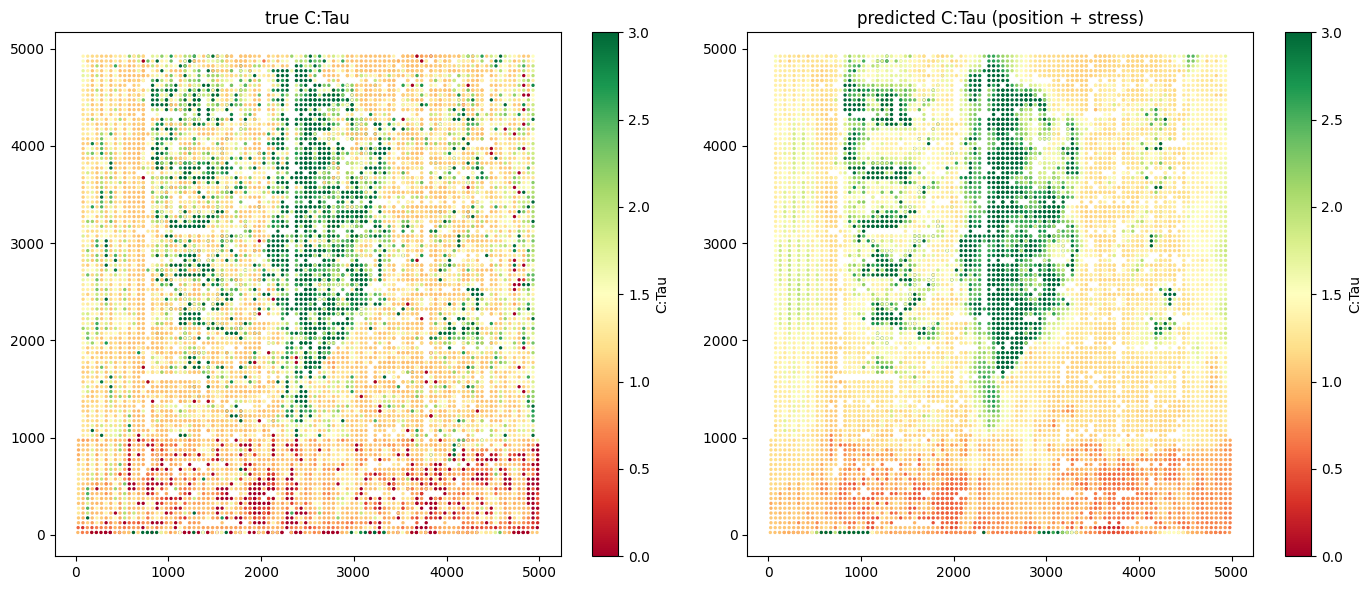

In [51]:
import matplotlib.pyplot as plt
# quick preview scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, title in zip(axes,
                           ['true_ctau', 'pred_ctau_stress'],
                           ['true C:Tau', 'predicted C:Tau (position + stress)']):
    sc = ax.scatter(pred_df['xpos'], pred_df['ypos'],
                    c=pred_df[col], cmap='RdYlGn',
                    s=2, vmin=0, vmax=3)
    plt.colorbar(sc, ax=ax, label='C:Tau')
    ax.set_title(title)
plt.tight_layout()
# plt.savefig('FERMzone0_gnn_ctauposstress.png')
plt.show()